# **Model Evaluation and Explainability**

This section evaluates model performance and explains predictions using:
- Confusion Matrix
- ROC-AUC Curve
- Precision-Recall Curve
- Feature Importance
- SHAP explanations

In [1]:
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import precision_recall_curve
import shap

**Data Preparation for Evaluation**

In [2]:
df = pd.read_csv("../data/credit_risk_clean.csv")

In [3]:
X = df.drop('loan_status', axis=1)
y = df['loan_status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [4]:
model = joblib.load("../models/xgboost_model.pkl")

In [5]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:,1]

**Confusion Matrix**

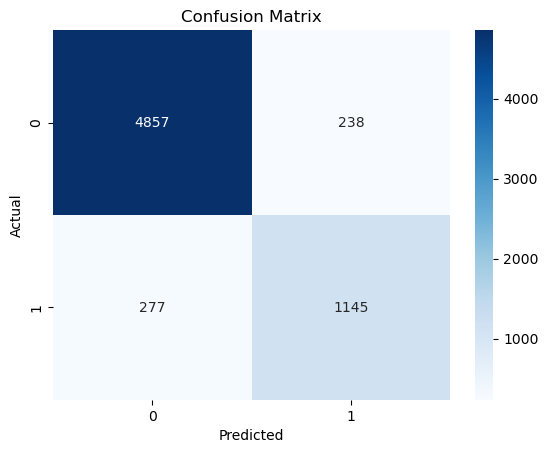

In [6]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

The confusion matrix shows how the model performs on correct and incorrect predictions. The model correctly identifies 4857 non-default loans and 1145 default loans. It incorrectly classifies 238 safe loans as defaults and misses 277 actual default cases. Overall, the model performs well, with most predictions being correct and a relatively small number of errors.

**Classification Report**

In [7]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95      5095
           1       0.83      0.81      0.82      1422

    accuracy                           0.92      6517
   macro avg       0.89      0.88      0.88      6517
weighted avg       0.92      0.92      0.92      6517



**ROC Curve and AUC Score**

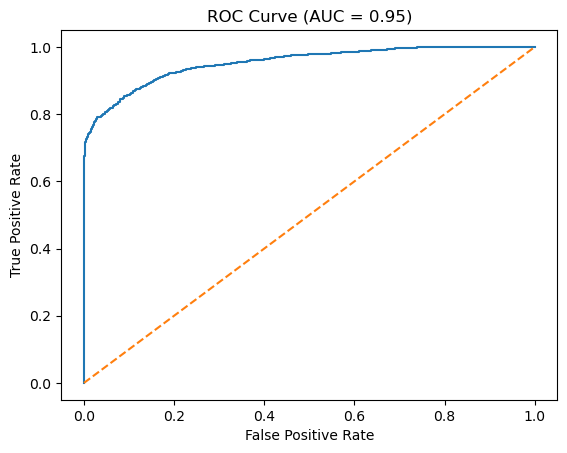

In [8]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')
plt.title(f"ROC Curve (AUC = {roc_auc:.2f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

The ROC curve shows the model’s ability to distinguish between default and non-default cases across all classification thresholds. The curve is very close to the top-left corner and far above the random baseline, which indicates strong predictive performance. The AUC value of 0.95 confirms that the model has excellent discrimination ability and can effectively separate risky borrowers from safe ones with high reliability.

**Precision-Recall Curve**

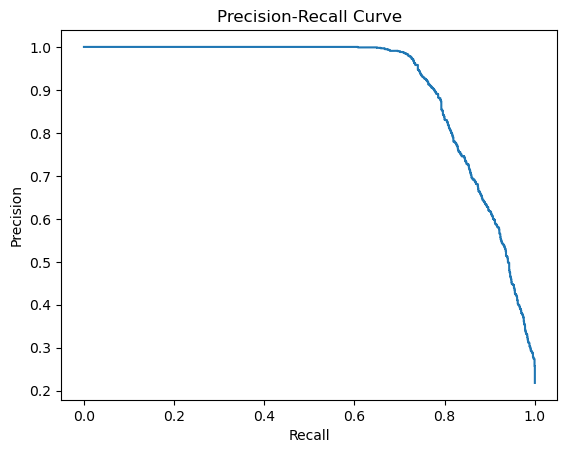

In [9]:
precision, recall, _ = precision_recall_curve(y_test, y_proba)

plt.plot(recall, precision)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

The precision-recall curve illustrates the trade-off between correctly identifying defaults and maintaining prediction accuracy. At low recall values, precision is very high, meaning the model is very accurate when it predicts a default. As recall increases, precision gradually decreases, which is expected because the model starts capturing more borderline cases. Even at higher recall levels, the model maintains relatively strong precision, showing a good balance between detecting defaults and avoiding too many false alarms.

**Feature Importance (XGBoost)**

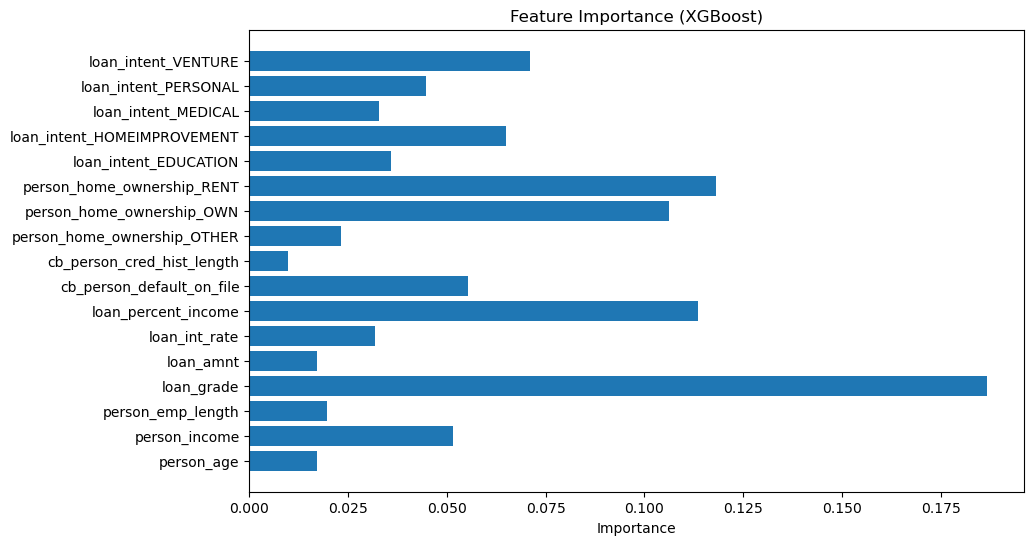

In [10]:
importances = model.feature_importances_
features = X.columns

plt.figure(figsize=(10,6))
plt.barh(features, importances)
plt.title("Feature Importance (XGBoost)")
plt.xlabel("Importance")
plt.show()

The model mainly relies on a small number of key features to make predictions. The most important feature is loan_grade, which has the strongest influence on whether a borrower will default or not. The second most important feature is person_home_ownership_RENT, followed closely by loan_percent_income and person_home_ownership_OWN.

This shows that both credit risk level and housing situation play a major role in predicting loan default. In particular, renting status is a strong risk indicator, which aligns with the EDA results where renters showed a much higher default rate compared to homeowners. Other features such as income, interest rate, and loan amount have moderate influence, while demographic variables like age and employment length contribute very little to the model’s decisions.

**SHAP Global Explanation**

In [11]:
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

 99%|===================| 6420/6517 [00:58<00:00]        

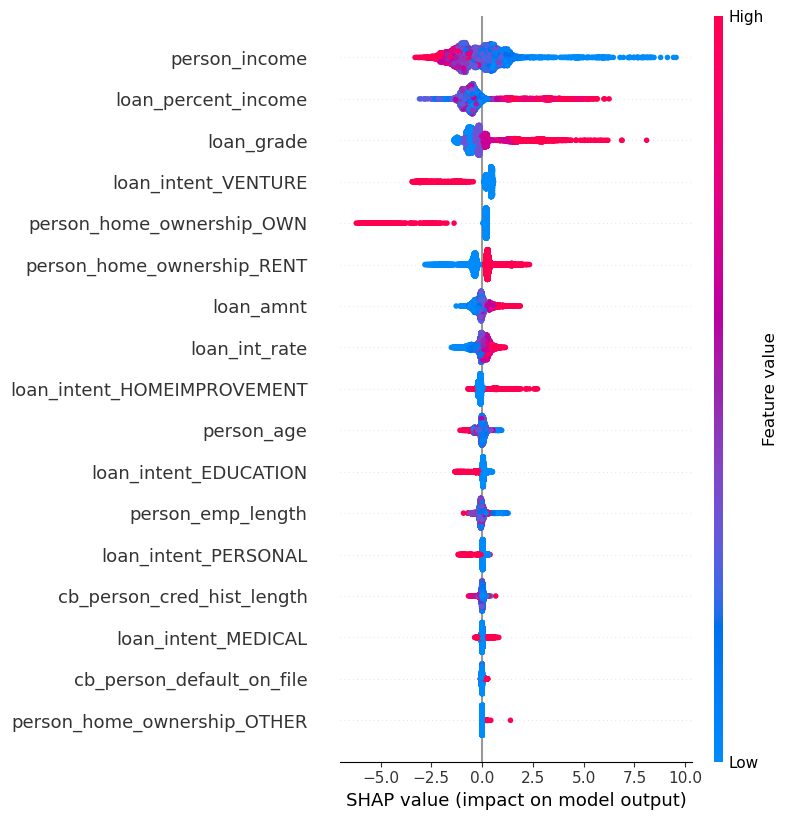

In [12]:
shap.summary_plot(shap_values, X_test)

This plot shows how each feature influences the model’s predictions across all samples. Features are ranked by importance from top to bottom.

loan_percent_income and loan_grade are the most influential variables. High debt-to-income values and risky credit grades strongly increase the probability of default, while low values reduce it.

person_income also plays an important role, but its effect is more mixed compared to financial ratio features.

Other variables such as age, employment length, and credit history have very small impact, as their SHAP values are mostly concentrated around zero.

**SHAP Local Explanation (Single Prediction)**

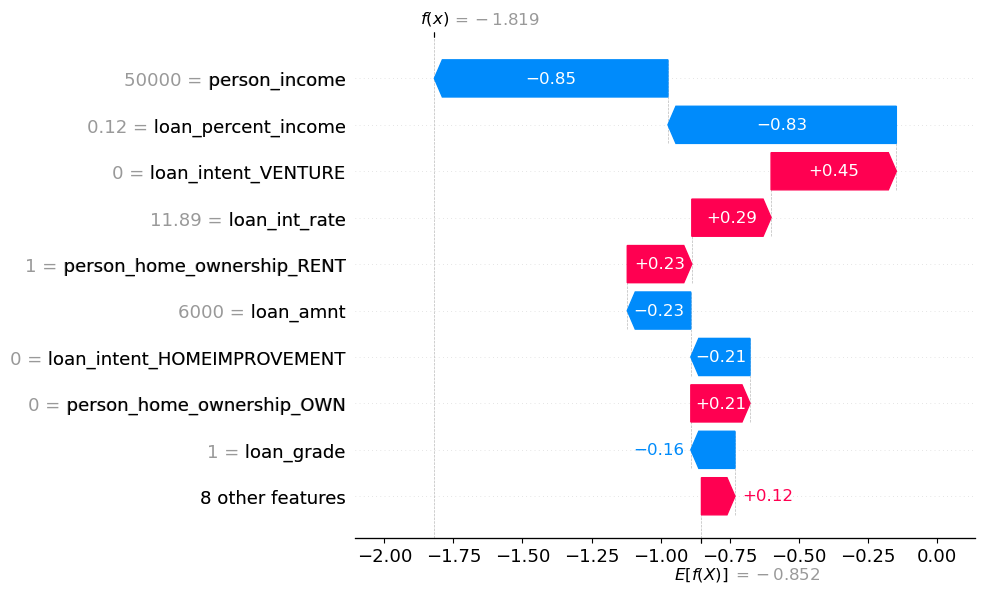

In [13]:
shap.plots.waterfall(shap_values[0])

This explanation corresponds to a single prediction from the test set

In [14]:
pred = model.predict(X_test.iloc[[0]])
proba = model.predict_proba(X_test.iloc[[0]])[:,1]

print("Prediction:", pred[0])
# probability that this specific loan will default
print("Default probability:", proba[0])

Prediction: 0
Default probability: 0.13954152


This plot explains how the model arrives at its prediction for one specific loan by showing how each feature moves the prediction from a baseline value.

The prediction starts from a baseline and is adjusted step by step by each feature.

The strongest factors reducing the risk of default are person_income and loan_percent_income. A high income and a low debt-to-income ratio significantly push the prediction toward non-default.

On the other hand, loan_intent_VENTURE, loan_int_rate, and renting status increase the probability of default, as they contribute positively toward risk.

Other features such as loan amount, loan grade, and additional loan intent variables have smaller effects on the final prediction.

Overall, the final decision results from the balance between strong protective financial factors and moderate risk-related features.